# 03 · SARSA, Q-learning, and exploration

[Course README](../README.md) · README topics **19–20**

**Goal.** Implement on-policy and off-policy TD control, distinguish training behavior from greedy evaluation, and visualize the learned routes.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/q-learning.svg" width="760" alt="Overview of SARSA, Q-learning, and exploration">

## 1. The cliff-walking task

The robot starts at the lower-left of a 4 × 12 grid and must reach the lower-right. The cells
between them in the bottom row form a cliff. Ordinary moves, including reaching the goal,
cost **−1**. A cliff move costs **−100** and sends the robot back to the start **without ending
the episode**. Going beyond the grid boundary leaves the robot in place.

We use γ = 1. A 1,000-step training cutoff prevents very long exploratory trajectories; it is
an external truncation, so its final transition still bootstraps. Reaching the goal is true
termination, so its final transition does not bootstrap.

**Analogy:** SARSA plans for the courier who sometimes explores near the cliff. Q-learning
learns the return of future greedy choices even while the courier collects exploratory data.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

Python 3.12.4 | NumPy 1.26.4


In [2]:
ROWS, COLS = 4, 12
N_STATES, N_ACTIONS = ROWS * COLS, 4
START, GOAL = (ROWS - 1) * COLS, ROWS * COLS - 1
DELTAS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

def step(state, action):
    """Deterministic cliff-walking dynamics; cliff falls reset but do not terminate."""
    row, col = divmod(state, COLS)
    dr, dc = DELTAS[action]
    row, col = np.clip(row + dr, 0, ROWS-1), np.clip(col + dc, 0, COLS-1)
    next_state = int(row * COLS + col)
    if row == ROWS-1 and 0 < col < COLS-1:
        return START, -100.0, False
    return next_state, -1.0, next_state == GOAL

def epsilon_greedy(q_row, epsilon, rng):
    """Explore uniformly; otherwise break ties randomly among maximizing actions."""
    if rng.random() < epsilon:
        return int(rng.integers(N_ACTIONS))
    best = np.flatnonzero(np.isclose(q_row, q_row.max(), atol=1e-12, rtol=0))
    return int(rng.choice(best))

assert step(START, 1) == (START, -100.0, False)
assert step(GOAL-COLS, 2) == (GOAL, -1.0, True)
print('Start:', START, '| goal:', GOAL, '| shortest safe route: 13 actions')

Start: 36 | goal: 47 | shortest safe route: 13 actions


## 2. Only the bootstrap action changes

```text
SARSA target      = reward + gamma * Q(next_state, sampled_next_action)
Q-learning target = reward + gamma * max_action Q(next_state, action)
```

Both targets reduce to the immediate reward at true termination. In SARSA the sampled next
action is **also the one executed next**. Resampling it after the update would break the intended
transition sequence. Q-learning's next behavior action can be chosen after updating Q.

In [3]:
def train(method, seed, episodes=500, epsilon=0.10, alpha=0.5, max_steps=1000):
    """Tabular control with fixed exploratory behavior; return Q and episode diagnostics."""
    if method not in {'SARSA', 'Q-learning'}: raise ValueError(method)
    rng = np.random.default_rng(seed)
    q = np.zeros((N_STATES, N_ACTIONS))
    returns = np.zeros(episodes)
    timeouts = 0
    for ep in range(episodes):
        state = START
        action = epsilon_greedy(q[state], epsilon, rng)
        for _ in range(max_steps):
            next_state, reward, terminated = step(state, action)
            next_action = None
            if terminated:
                target = reward
            elif method == 'SARSA':
                next_action = epsilon_greedy(q[next_state], epsilon, rng)
                target = reward + q[next_state, next_action]
            else:
                target = reward + q[next_state].max()
            q[state, action] += alpha * (target - q[state, action])
            returns[ep] += reward
            if terminated: break
            state = next_state
            action = next_action if method == 'SARSA' else epsilon_greedy(q[state], epsilon, rng)
        else:
            timeouts += 1
    return q, returns, timeouts

# Hand calculation: same transition, different policies in the target.
assert np.isclose(-1 + 0.9 * 2, 0.8)       # SARSA sampled the action valued at 2.
assert np.isclose(-1 + 0.9 * max(8, 2), 6.2)

## 3. Compare training behavior across seeds

We keep exploration at 0.10 to make its consequences visible. Curves report exploratory
training returns, not the performance of an exploration-free deployed policy. Seeds are
independent runs; the two algorithms do not necessarily visit the same states.

SARSA      | final 100-episode mean return: -25.6 | cutoffs: 0
Q-learning | final 100-episode mean return: -54.8 | cutoffs: 0


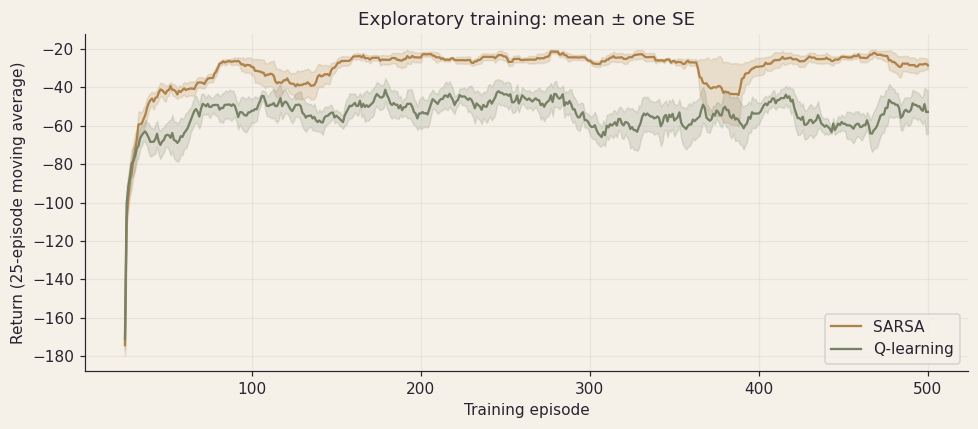

In [4]:
SEEDS = [7, 19, 31, 43, 59]
results = {method: [train(method, seed) for seed in SEEDS] for method in ['SARSA', 'Q-learning']}
fig, ax = plt.subplots(figsize=(9, 4))
window = 25
for method, runs in results.items():
    curves = np.stack([np.convolve(run[1], np.ones(window)/window, mode='valid') for run in runs])
    mean, se = curves.mean(axis=0), curves.std(axis=0, ddof=1)/np.sqrt(len(SEEDS))
    x = np.arange(window, window + len(mean))
    line, = ax.plot(x, mean, label=method)
    ax.fill_between(x, mean-se, mean+se, color=line.get_color(), alpha=0.18)
    print(f'{method:10s} | final 100-episode mean return: {np.mean([r[1][-100:].mean() for r in runs]):.1f} | cutoffs: {sum(r[2] for r in runs)}')
ax.set(xlabel='Training episode', ylabel='Return (25-episode moving average)', title='Exploratory training: mean ± one SE')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Evaluate frozen greedy policies separately

During evaluation we make **no updates** and set exploration to zero. A fixed argmax tie
rule makes the displayed route deterministic. An unfinished evaluation is reported as a
failure, rather than quietly omitted. The plot shows the first training seed; it is an
illustration, while the printed diagnostics cover every seed.

SARSA greedy returns: [-17.0, -17.0, -17.0, -100.0, -19.0] | successes: 4 / 5


Q-learning greedy returns: [-13.0, -13.0, -13.0, -13.0, -13.0] | successes: 5 / 5


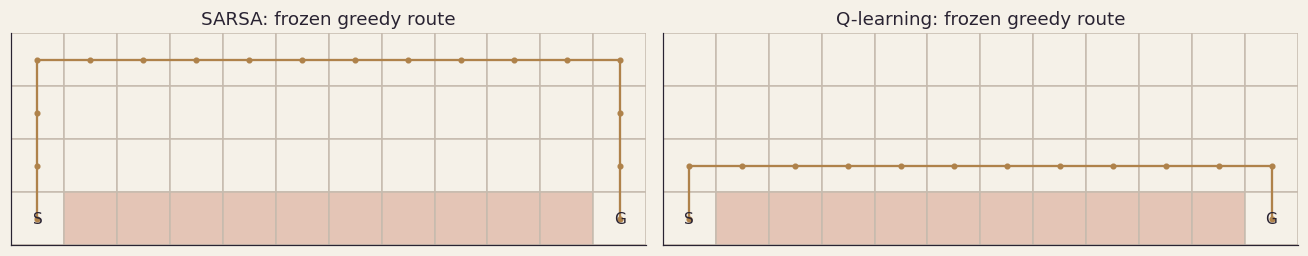

In [5]:
def greedy_rollout(q, max_steps=100):
    """Evaluate without exploration or learning; return visited states, return, success."""
    state, total, path = START, 0.0, [START]
    for _ in range(max_steps):
        state, reward, terminated = step(state, int(q[state].argmax()))
        path.append(state); total += reward
        if terminated: return path, total, True
    return path, total, False

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (method, runs) in zip(axes, results.items()):
    evaluations = [greedy_rollout(q) for q, _, _ in runs]
    print(method, 'greedy returns:', [e[1] for e in evaluations], '| successes:', sum(e[2] for e in evaluations), '/', len(SEEDS))
    assert all(np.isfinite(q).all() for q, _, _ in runs)
    path = evaluations[0][0]
    for row in range(ROWS):
        for col in range(COLS):
            color = '#E4C5B6' if row == ROWS-1 and 0 < col < COLS-1 else PAPER
            ax.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, facecolor=color, edgecolor='#C6BBAE'))
    ax.plot([s % COLS for s in path], [s // COLS for s in path], '-o', color=GOLD, markersize=3)
    ax.text(0, ROWS-1, 'S', ha='center', va='center'); ax.text(COLS-1, ROWS-1, 'G', ha='center', va='center')
    ax.set(xlim=(-.5, COLS-.5), ylim=(ROWS-.5, -.5), title=f'{method}: frozen greedy route', xticks=[], yticks=[])
    ax.set_aspect('equal'); ax.grid(False)
plt.tight_layout(); plt.show()

SARSA can learn a wider safety margin because its target includes the future cost of
exploration. Q-learning can learn a shorter greedy route yet suffer more cliff penalties
while collecting exploratory data. These are different evaluation questions. Fixed epsilon
and fixed alpha also mean this experiment is not a demonstration of the asymptotic
convergence theorem, which requires additional coverage and step-size conditions.

In the saved run, SARSA reaches the goal for four of five frozen greedy policies. One policy loops until the 100-step evaluation cutoff (return −100). With only 500 training episodes and a fixed learning rate, greedy success is not guaranteed for every seed. Compare this with its exploratory training returns, and try longer training as an exercise.

## Exercises

1. Increase epsilon to 0.25. Compare training returns and frozen-policy evaluation.
2. Decay epsilon slowly toward zero. How do the routes change?
3. Change the cliff penalty to −10.
4. Add evaluation at epsilon=0.10 using a separate random generator.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. More exploratory mistakes can make a safety margin valuable.
2. Policy differences can shrink as exploration vanishes.
3. The incentive to avoid cliff resets is weaker.
4. Use a fresh seed and never update Q during evaluation; report success and cutoffs as well as return.

</details>

## What to remember

Behavior and target policies are distinct. The quality of greedy deployment and the cost of exploratory learning should be measured separately.

## Further reading

- Sutton and Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html). Chapter 6, especially cliff walking.

[← Previous notebook](02_mc_vs_td.ipynb) · [Next notebook →](04_dqn.ipynb)